### 1) Import Pandas and Numpy

In [1]:
import numpy as np
import pandas as pd

### 2) Import the dataset and  Assign it to a variable called Chipo

#### Import the dataset from
https://github.com/justmarkham/pandas-videos/blob/master/data/chipotle.tsv

#### REMEMBER: It is a .tsv file , you will have to do some research on how to read .tsv files first!

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pandas-videos/refs/heads/master/data/chipotle.tsv"
chipo = pd.read_table(url)

### 3) See the first 10 entries

In [3]:
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### 4) What is the number of observations in the dataset?

In [4]:
len(chipo)

4622

### 5) What is the number of columns in the dataset?

In [5]:
len(chipo.columns)

5

### 6) Print the name of all the columns.

In [6]:
for i in chipo.columns:
    print(i)

order_id
quantity
item_name
choice_description
item_price


### 7) Which was the most-ordered item?

In [7]:
print(chipo.groupby('item_name').quantity.sum().sort_values().tail(1).index[0])
#chipo.mode()

Chicken Bowl


### 8) For the most-ordered item, how many items were ordered?

In [8]:
print(chipo.groupby('item_name').quantity.sum().sort_values().tail(1).values[0])

761


### 9) What was the most ordered item in the choice_description column?

In [9]:
for i in chipo.groupby('choice_description').quantity.sum().sort_values(ascending=False).head(1).index:
    print(i)


[Diet Coke]


### 10) How many items were ordered in total?

In [10]:
print(chipo.quantity.sum())

4972


### 11) Turn the item price into a float

In [11]:
chipo['item_price'] = chipo['item_price'].str.replace("$","",regex=False)
chipo['item_price'] = chipo['item_price'].astype(float)

### 12) How much was the revenue for the period in the dataset?
#### Revenue will be the sum of quantity * item_price!

In [12]:
sum = 0
len(chipo)
for i in range(len(chipo)):
    sum += (chipo.loc[i].quantity)*(chipo.loc[i].item_price)

print(sum,end='')   

39237.020000000055

### 13) How many orders were made in the period?

In [13]:
len(chipo[chipo['order_id'].duplicated() == False])

1834

### 14) What is the average revenue amount per order?

In [14]:
print(chipo.groupby('order_id').item_price.sum().mean())

18.811428571428568


### 15) How many different items are sold?

In [15]:
len(chipo[chipo['item_name'].duplicated() == False])

50

### 16) Show a histogram with number of orders with bill on the x-axis.

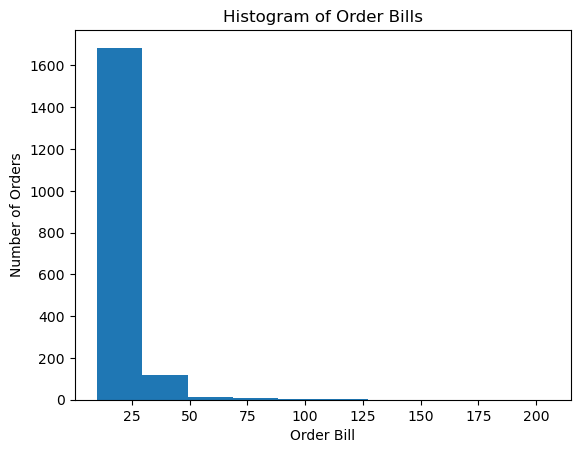

In [16]:
import matplotlib.pyplot as plt

plt.hist(chipo.groupby('order_id').item_price.sum())
plt.xlabel("Order Bill")
plt.ylabel("Number of Orders")
plt.title("Histogram of Order Bills")
plt.show()